In [11]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, roc_auc_score, classification_report, roc_curve

### Colors 

In [12]:
sns.set_theme(style="whitegrid", palette="Greys_r")
plt.rcParams["figure.figsize"] = (12, 6)   # más compactas
plt.rcParams["figure.dpi"] = 100

red_grey = mcolors.LinearSegmentedColormap.from_list(
    "RedGrey",
    ["#bfbfbf96", "#c60f0f"]  # gris → rojo
)

### Functions 

In [ ]:
def evaluate_model_with_shap(model, X_train: pd.DataFrame, y_train: pd.Series | np.ndarray, X_test: pd.DataFrame, y_test: pd.Series | np.ndarray, model_name: str = "Modelo", top_n: int = 10, shap_sample: int = 1000) -> float:
    """
    Evaluate a tree-based model and generate SHAP explainability plots.

    This function computes the multiclass ROC AUC score, displays model
    feature importance when available, and produces SHAP visualizations
    for feature importance and impact per class.

    Parameters
    ----------
    model : object
        Trained model supporting predict_proba and compatible with SHAP.
    X_train : pd.DataFrame
        Training feature dataset.
    y_train : array-like
        Training target labels.
    X_test : pd.DataFrame
        Test feature dataset.
    y_test : array-like
        True labels for the test dataset.
    model_name : str
        Model name used in printed metrics and plots.
    top_n : int
        Number of most important features displayed.
    shap_sample : int
        Maximum number of samples used to compute SHAP values.

    Returns
    -------
    float
        Macro ROC AUC score.
    """
    y_proba = model.predict_proba(X_test)
    auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    print(f"{model_name} AUC: {auc_score:.4f}")

    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({"feature": X_train.columns, "importance": model.feature_importances_}).sort_values("importance")
        imp.tail(top_n).plot.barh(x="feature", y="importance", figsize=(8,6))
        plt.grid(True)
        plt.title("Model Feature Importance")
        plt.show()

    print("Calculando SHAP...")

    X_shap = X_test.sample(min(shap_sample, len(X_test)), random_state=42).astype(float)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=top_n)

    class_names = ["Poor", "Standard", "Good"]

    for i, name in enumerate(class_names):

        fig, axes = plt.subplots(1, 2, figsize=(14,5))

        plt.sca(axes[0])
        shap.summary_plot(shap_values[i], X_shap, plot_type="dot", max_display=top_n, show=False)
        axes[0].set_title(f"{name} Impact")

        plt.sca(axes[1])
        shap.summary_plot(shap_values[i], X_shap, plot_type="bar", max_display=top_n, show=False)
        axes[1].set_title(f"{name} Importance")

        plt.tight_layout()
        plt.show()

    return auc_score


def _normalize_shap_values(shap_values, X: pd.DataFrame, class_idx: int = 0) -> np.ndarray:
    """
    Normalize SHAP values format for multiclass models.

    This function converts SHAP outputs into a consistent
    2D matrix (samples × features) for a selected class.

    Parameters
    ----------
    shap_values : array-like or list
        Raw SHAP values returned by the explainer.
    X : pd.DataFrame
        Dataset used to compute SHAP values.
    class_idx : int
        Index of the class to extract.

    Returns
    -------
    np.ndarray
        SHAP values matrix aligned with X.
    """
    if isinstance(shap_values, list):
        shap_values = shap_values[class_idx]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, class_idx]

    assert shap_values.shape == X.shape, (
        f"SHAP shape {shap_values.shape} != X shape {X.shape}"
    )

    return shap_values


def plot_global_shap_multiclass(raw_shap, X: pd.DataFrame, top_n: int = 10, class_names: tuple[str, str, str] = ("Class 0","Class 1","Class 2")) -> None:
    """
    Plot global SHAP feature importance for a multiclass model.

    This visualization aggregates mean absolute SHAP values and
    displays them as a stacked bar chart showing contribution
    per class.

    Parameters
    ----------
    raw_shap : array-like or list
        Raw SHAP values returned by the explainer.
    X : pd.DataFrame
        Dataset used for SHAP computation.
    top_n : int
        Number of top features displayed.
    class_names : tuple
        Names of the classes.
    """
    if isinstance(raw_shap, list):
        shap_array = np.stack(raw_shap, axis=2)
    else:
        shap_array = raw_shap

    mean_abs = np.mean(np.abs(shap_array), axis=0)

    total_importance = mean_abs.sum(axis=1)
    top_idx = np.argsort(total_importance)[-top_n:]

    features = X.columns[top_idx]
    values = mean_abs[top_idx]

    plt.figure(figsize=(12,6))

    bottom = np.zeros(len(top_idx))

    for i in range(values.shape[1]):
        plt.barh(features, values[:, i], left=bottom, label=class_names[i])
        bottom += values[:, i]

    plt.xlabel("mean(|SHAP value|) (average impact magnitude)")
    plt.title("Global Feature Importance (Multiclass)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def shap_multiclass_full_report(model, X: pd.DataFrame, class_names: tuple[str, str, str] = ("Poor","Standard","Good"), top_n: int = 10, sample_size: int = 1000) -> None:
    """
    Generate a full SHAP explainability report for a multiclass model.

    The report includes SHAP impact plots, feature importance plots
    for each class, and a global multiclass feature importance chart.

    Parameters
    ----------
    model : object
        Trained model compatible with SHAP.
    X : pd.DataFrame
        Dataset used for SHAP evaluation.
    class_names : tuple
        Names of the classes.
    top_n : int
        Number of top features displayed in each plot.
    sample_size : int
        Maximum number of samples used for SHAP computation.
    """
    X_shap = X.sample(min(sample_size, len(X)), random_state=42).astype(float)
    explainer = shap.TreeExplainer(model)
    raw_shap = explainer.shap_values(X_shap)

    for i, name in enumerate(class_names):

        shap_values = _normalize_shap_values(raw_shap, X_shap, class_idx=i)

        fig, axes = plt.subplots(1, 2, figsize=(12,6), gridspec_kw={"width_ratios": [2,1]})

        fig.suptitle(f"Class: {name}", fontsize=12, fontweight="bold")

        plt.sca(axes[0])
        shap.summary_plot(shap_values, X_shap, plot_type="dot", max_display=10, cmap=red_grey, show=False)
        axes[0].set_title("SHAP Impact", fontsize=9)

        plt.sca(axes[1])
        shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=10, color="#6e6e6e", show=False)

        axes[1].set_yticklabels([])
        axes[1].set_ylabel("")
        axes[1].set_title("Feature Importance", fontsize=9)

        fig.set_size_inches(12,6)

        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(12,6))

    plot_global_shap_multiclass(raw_shap, X_shap, top_n=top_n, class_names=class_names)


def plot_probability_density(y_test: pd.Series | np.ndarray, proba: np.ndarray, model_name: str = "Modelo", class_names: tuple[str, str, str] = ("Poor","Standard","Good")) -> None:
    """
    Plot kernel density estimation of predicted probabilities.

    This visualization shows how probability estimates differ
    across the true classes.

    Parameters
    ----------
    y_test : array-like
        True class labels.
    proba : np.ndarray
        Predicted class probabilities.
    model_name : str
        Model name used in the plot title.
    class_names : tuple
        Names of the classes.
    """
    y_test = np.array(y_test)

    plt.figure()

    for i, name in enumerate(class_names):

        sns.kdeplot(
            proba[y_test == i, i],
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=name
        )

    plt.title(f"Probability Density - {model_name}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_xgb_importance(model, X: pd.DataFrame, importance_type: str = "gain", top_n: int = 10) -> None:
    """
    Plot feature importance from an XGBoost model.

    The function extracts importance scores from the trained booster
    and displays the top features.

    Parameters
    ----------
    model : XGBoost model
        Trained XGBoost classifier or regressor.
    X : pd.DataFrame
        Dataset used for training (needed for feature names).
    importance_type : str
        Importance metric used by XGBoost (e.g., "gain", "weight", "cover").
    top_n : int
        Number of most important features displayed.
    """
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    imp = pd.DataFrame({
        "feature": list(score.keys()),
        "importance": list(score.values())
    })

    if all(f.startswith("f") for f in imp["feature"]):
        feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
        imp["feature"] = imp["feature"].map(feature_map)

    imp = imp.sort_values("importance").tail(top_n)

    plt.figure(figsize=(12,6))
    plt.barh(imp["feature"], imp["importance"])
    plt.xlabel(f"XGBoost Importance ({importance_type})")
    plt.title(f"Top {top_n} Features - {importance_type}")
    plt.tight_layout()
    plt.show()

---

In [14]:
df = pd.read_csv("clean_train.csv")

mapping = {
    "Poor": 0,
    "Standard": 1,
    "Good": 2
}

y = df["Credit_Score"].map(mapping)


X = df.drop("Credit_Score", axis=1)

X = pd.get_dummies(X, drop_first=True).astype(float)

selected_features = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Changed_Credit_Limit',
    'Total_EMI_per_month',
    'Credit_Mix_Standard',
    'Credit_Mix_Good',
    'Payment_of_Min_Amount_Yes'
]

X = X[selected_features]

### Model XGBoost

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

model = XGBClassifier(
    objective="multi:softprob",   
    num_class=3,                  
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76      5799
           1       0.79      0.80      0.79     10635
           2       0.71      0.71      0.71      3566

    accuracy                           0.77     20000
   macro avg       0.76      0.75      0.76     20000
weighted avg       0.77      0.77      0.77     20000

AUC: 0.8956157671153622


In [18]:
explainer = shap.TreeExplainer(model)
raw_shap = explainer.shap_values(X_test)

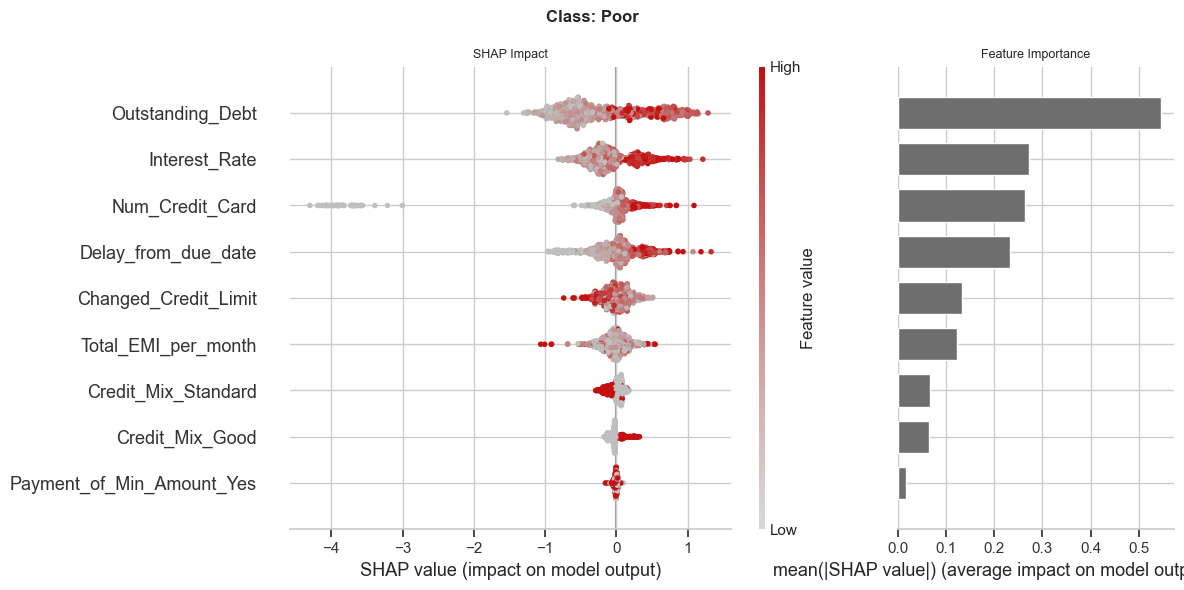

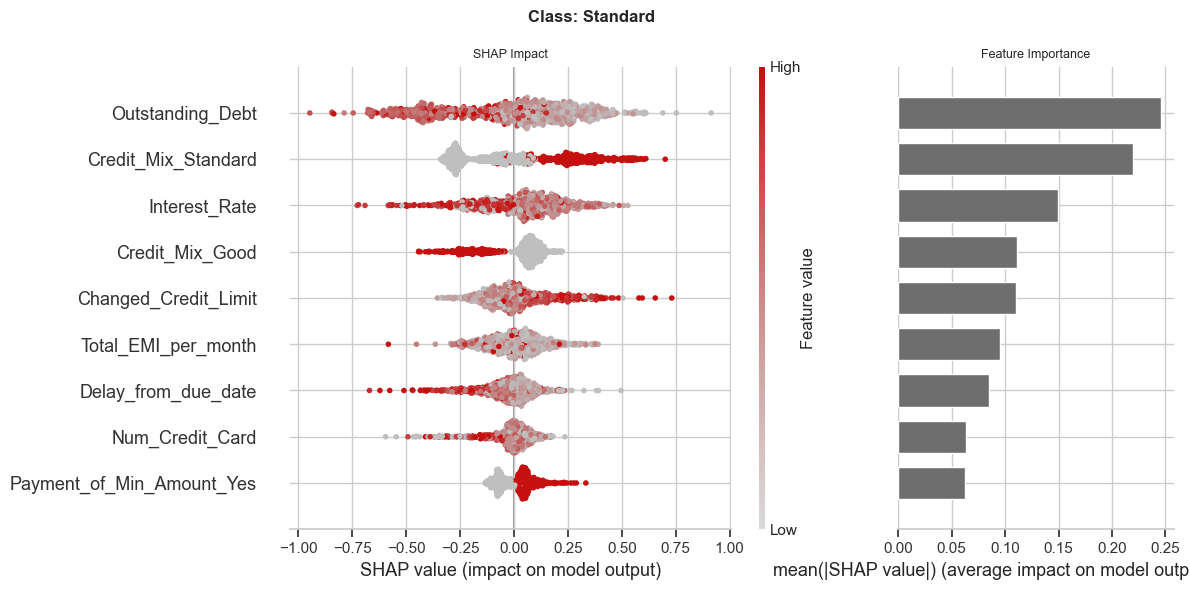

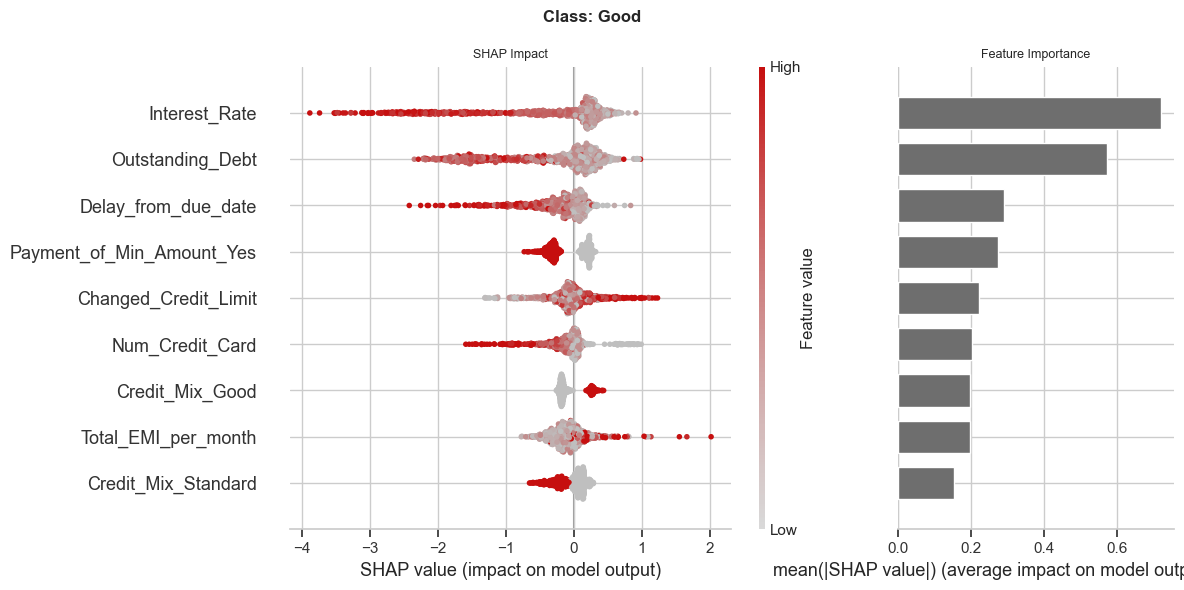

<Figure size 1200x600 with 0 Axes>

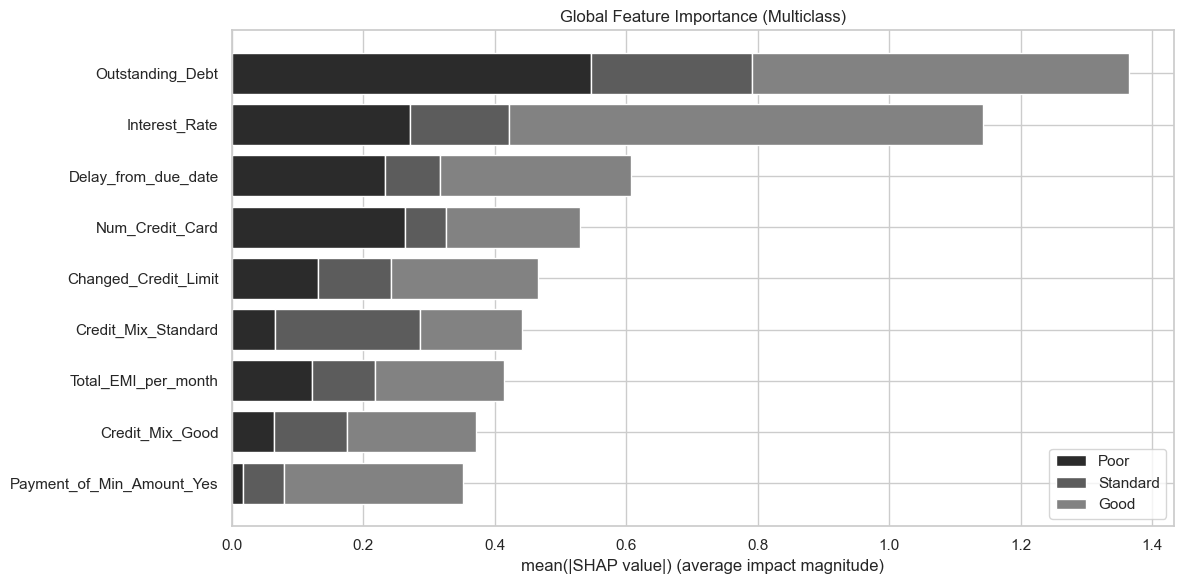

In [19]:
shap_multiclass_full_report(
    model=model,
    X=X_test,
    class_names=("Poor","Standard","Good"),
    top_n=10,
    sample_size=1000,
)

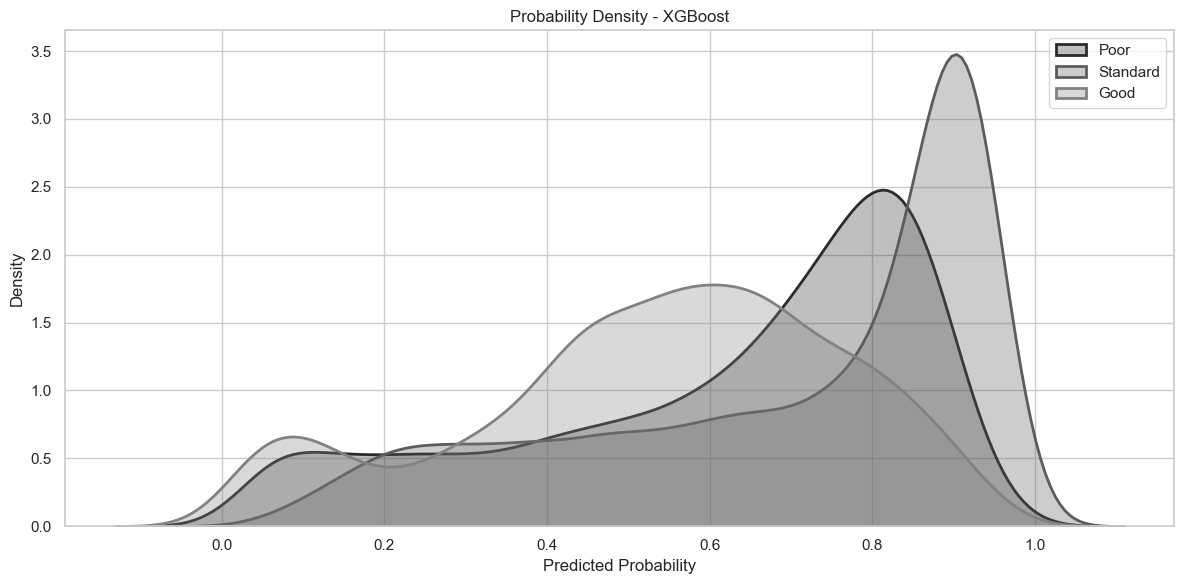

In [20]:
plot_probability_density(
    y_test,
    y_proba,
    model_name="XGBoost"
)

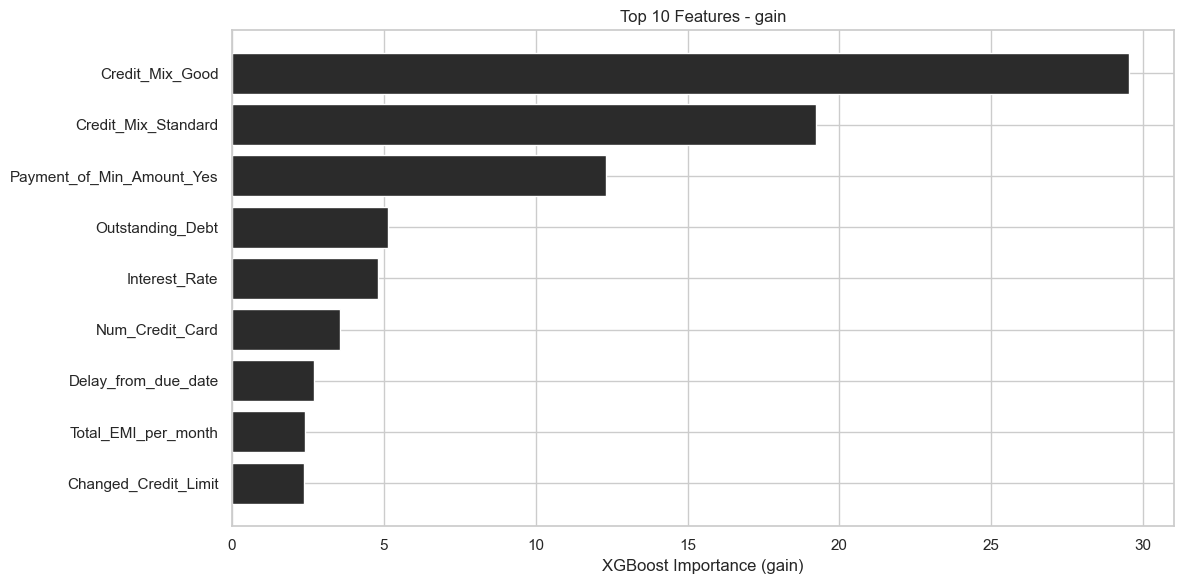

In [21]:
plot_xgb_importance(model, X_test, importance_type="gain")

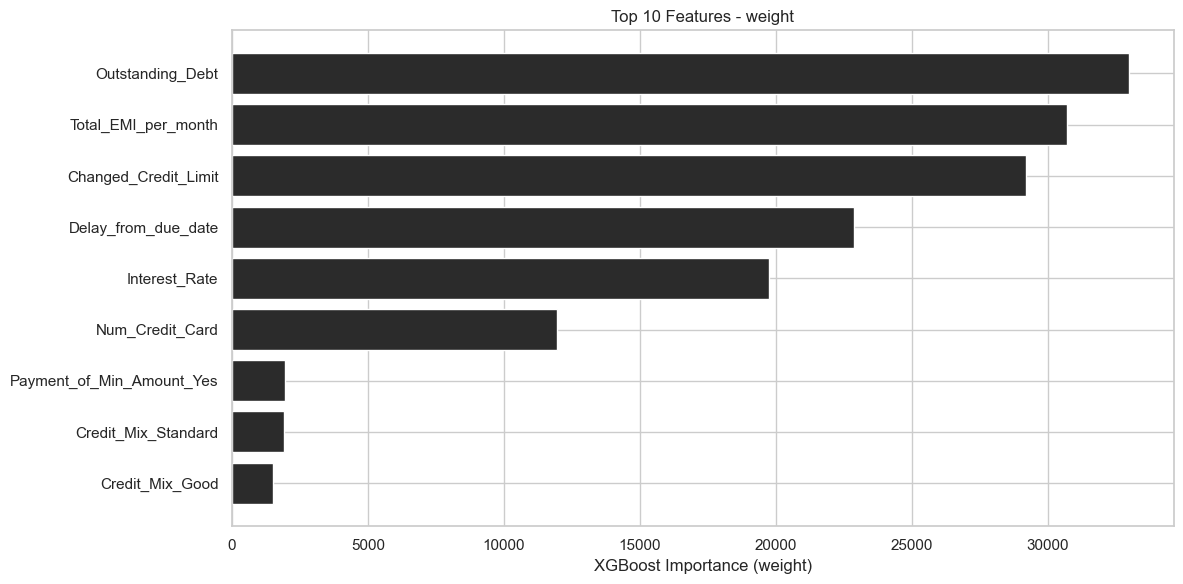

In [22]:
plot_xgb_importance(model, X_test, importance_type="weight")